# Customer Lifetime Value (CLV) Prediction and Segmentation

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from datetime import timedelta
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,mean_absolute_error,mean_squared_error,r2_score


### Loading Dataset

In [138]:
df=pd.read_csv('Dataset.csv',encoding='latin3')

In [139]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### Data Cleaning

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [141]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                         Description  Quantity  \
0         536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                 WHITE METAL LANTERN         6   
2         536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G      CREAM CUPID HEARTS COAT HANGER         6   
4         536365    84029E      CREAM CUPID HEARTS COAT HANGER         6   
...          ...       ...                                 ...       ...   
541904    581587     22613         PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899        CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254       CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255     CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138       BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID       

In [142]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(5268)

In [144]:
df.shape

(541909, 8)

In [145]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,CREAM CUPID HEARTS COAT HANGER,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [146]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [147]:
df=df.dropna(subset=['CustomerID'])

In [148]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [149]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [150]:
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 406829, dtype: datetime64[ns]

In [151]:
count=len(df)
df=df[df['Quantity']>0] ##Remove Return Product
df=df[df['UnitPrice']>0] ## Remove Invalid Price
removed_rows=count-len(df)
print(f"Removed Invalid Rows are:{removed_rows}") 

Removed Invalid Rows are:8945


In [152]:
print(f"Remaining Rows are:- {len(df)}")

Remaining Rows are:- 397884


In [153]:
df['Revenue']=df['Quantity']*df['UnitPrice']

In [154]:
df.shape

(397884, 9)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


### Distribution of Purchased Quantity

In [156]:
''' 
The Distribution of Purchased quantity was analysisted to understand 
Customer buying bhevaiour 
''';

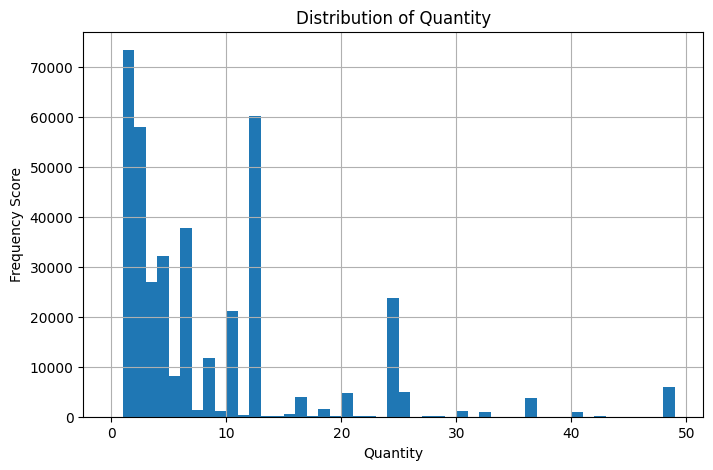

In [157]:

plt.figure(figsize=(8,5))
plt.hist(df['Quantity'],bins=range(0,50))
plt.title("Distribution of Quantity") 
plt.xlabel('Quantity')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [158]:
'''
Observation:- 
Most transactions contains small purchased quantity,
while few transactions involves large purchased quantity
''';

### Distribution of Unit Price

In [159]:
''' 
Distribution of Selling Price of product were analysisted 
''';

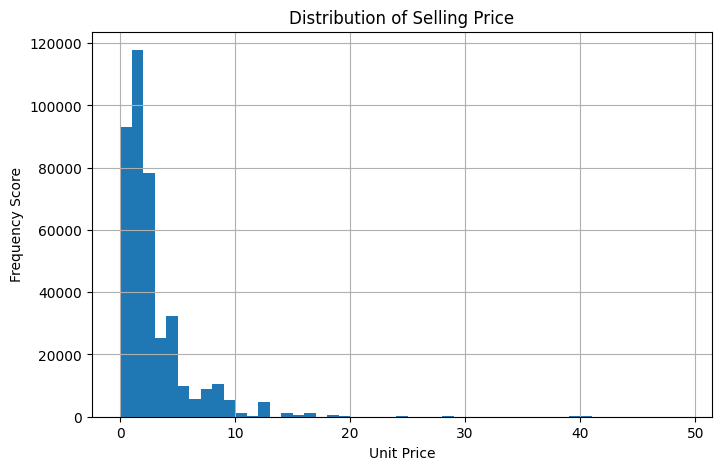

In [160]:
plt.figure(figsize=(8,5))
plt.hist(df['UnitPrice'],bins=range(0,50))
plt.title("Distribution of Selling Price") 
plt.xlabel('Unit Price')
plt.ylabel('Frequency Score')
plt.grid()
plt.show()

In [161]:
revenue_customer=df.groupby('CustomerID')['Revenue'].sum().reset_index()

In [162]:
revenue_customer

,CustomerID,Revenue
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


### Distribution of Revenue Per Customer

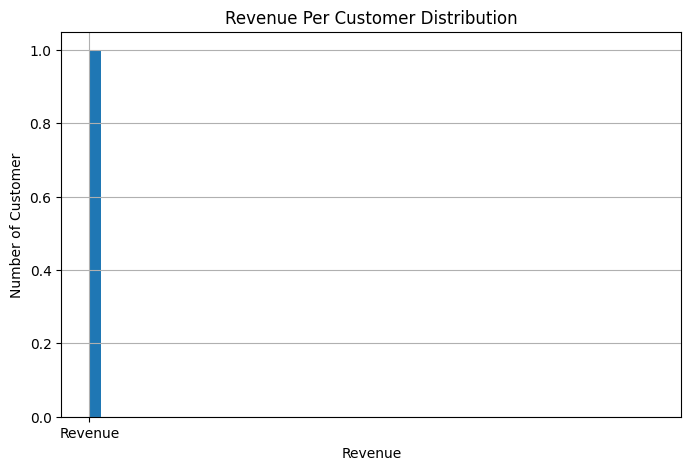

In [163]:
plt.figure(figsize=(8,5))
plt.hist('Revenue',bins=range(0,50))
plt.title('Revenue Per Customer Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Customer')
plt.grid()
plt.show()

# Purchase Frequency Per Customer 

In [164]:
purchase_frequency=(
    df.groupby('CustomerID')['InvoiceNo'].nunique()
    .reset_index(name='PurchaseFrequency')
)
purchase_frequency.head()

,CustomerID,PurchaseFrequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


# Purchase Frequency Distribution

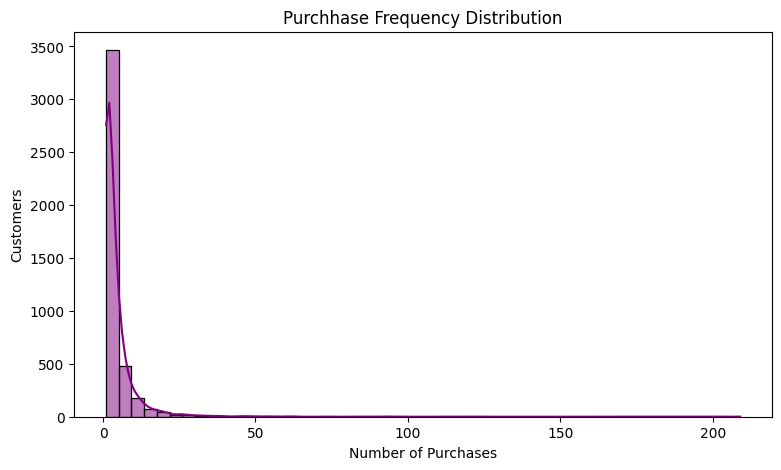

In [165]:
plt.figure(figsize=(9,5))
sns.histplot(
    purchase_frequency['PurchaseFrequency'],
    bins=50,
    kde=True,
    color='purple'

)
plt.title("Purchhase Frequency Distribution")
plt.xlabel('Number of Purchases')
plt.ylabel('Customers')
plt.show()

# Calculate RFM Features

In [166]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'Revenue': 'sum'

})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# Scatter Plot (Recency vs Monetary)

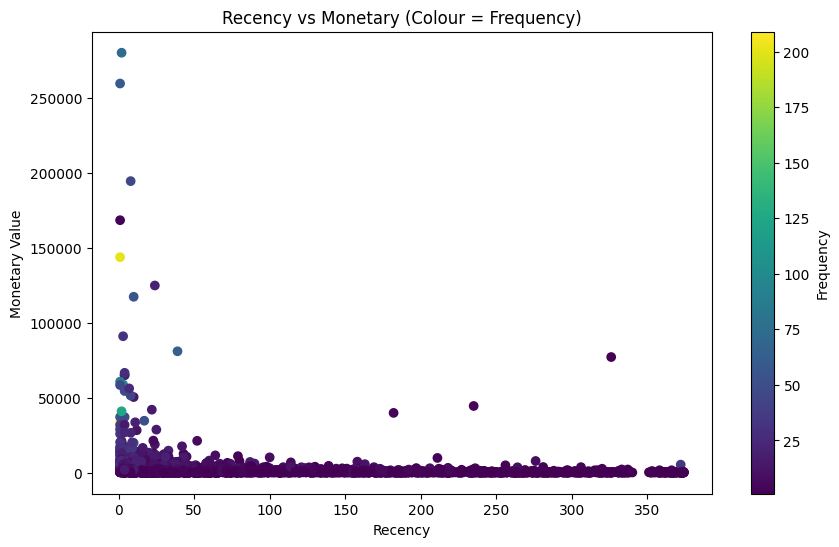

In [167]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Frequency'],
    cmap='viridis'
)

plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.title("Recency vs Monetary (Colour = Frequency)")

plt.colorbar(scatter, label='Frequency')

plt.show()

# Country-wise Customer Count

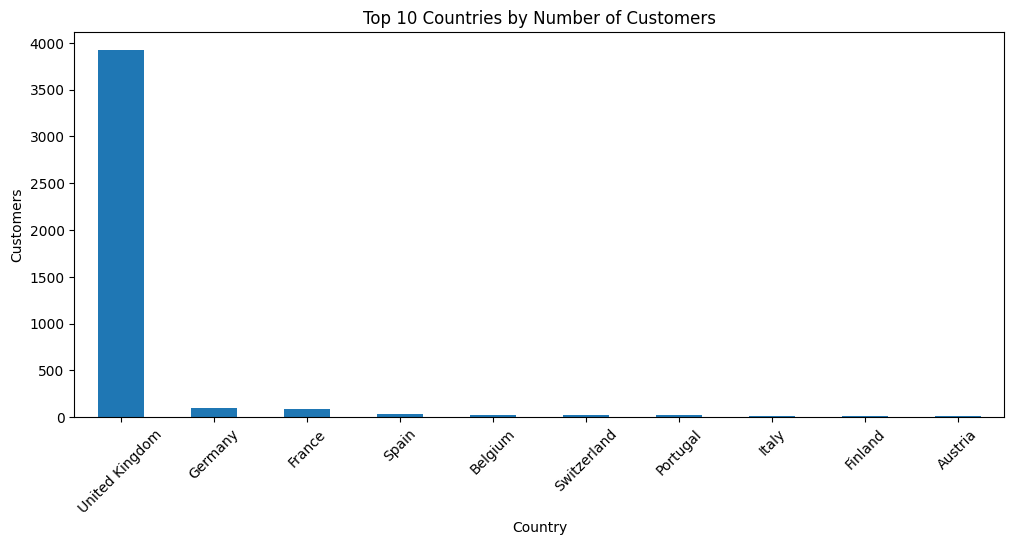

In [168]:
country_customer = (
    df.groupby('Country')['CustomerID']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

country_customer.plot(kind='bar')

plt.title("Top 10 Countries by Number of Customers")

plt.xlabel("Country")

plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

# Country-wise Average CLV (Revenue)

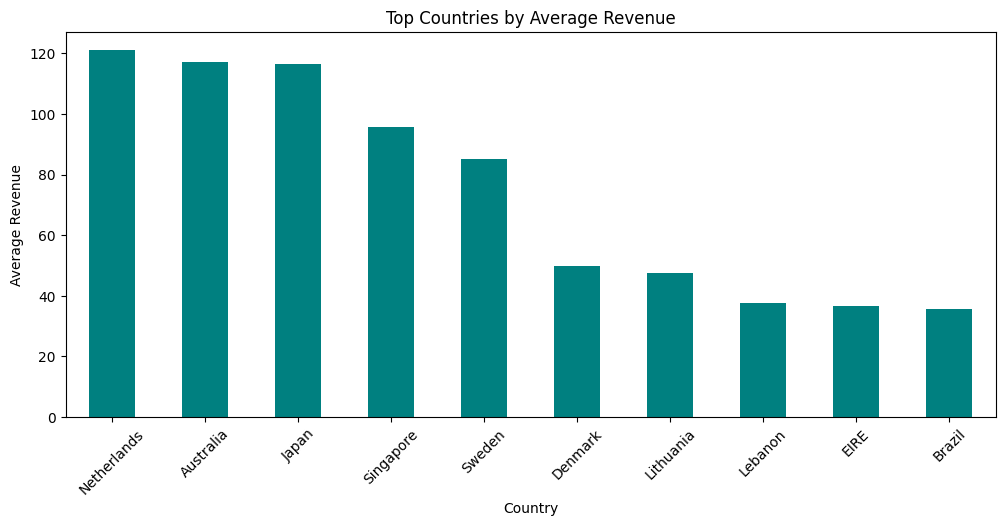

In [169]:
country_revenue = (
    df.groupby('Country')['Revenue']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

country_revenue.plot(kind='bar', color='teal')

plt.title("Top Countries by Average Revenue")

plt.xlabel("Country")

plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()

# Data Preprocessing & CLV Target Creation

#### Define the Cutoff Date

In [170]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2011-09-10 12:50:00


# Split Dataset into Past and Future Transactions

In [171]:

past_data = df[df['InvoiceDate'] <= cutoff_date]

future_data = df[df['InvoiceDate'] > cutoff_date]

print("Past Transactions :", past_data.shape)
print("Future Transactions :", future_data.shape)


Past Transactions : (236358, 9)
Future Transactions : (161526, 9)


# Create RFM Features from Past Data

In [172]:

reference_date = past_data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = past_data.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (reference_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'Revenue': 'sum'

})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,235,1,77183.60
12347.0,39,5,2790.86
12348.0,158,3,1487.24
12350.0,219,1,334.40
12352.0,171,5,1561.81


# Create Future CLV Target

In [173]:
future_clv = future_data.groupby('CustomerID')['Revenue'].sum().reset_index()

future_clv.columns = ['CustomerID','CLV']

future_clv.head()

,CustomerID,CLV
0,12347.0,1519.14
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


# Merge RFM Features with CLV Target

In [174]:
final_df = rfm.merge(
    future_clv,
    on='CustomerID',
    how='left'
)

final_df['CLV'] = final_df['CLV'].fillna(0)

final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


# Check Dataset Shape

In [175]:
print(final_df.shape)

final_df.head()

(3370, 5)


,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


# Check Outliers

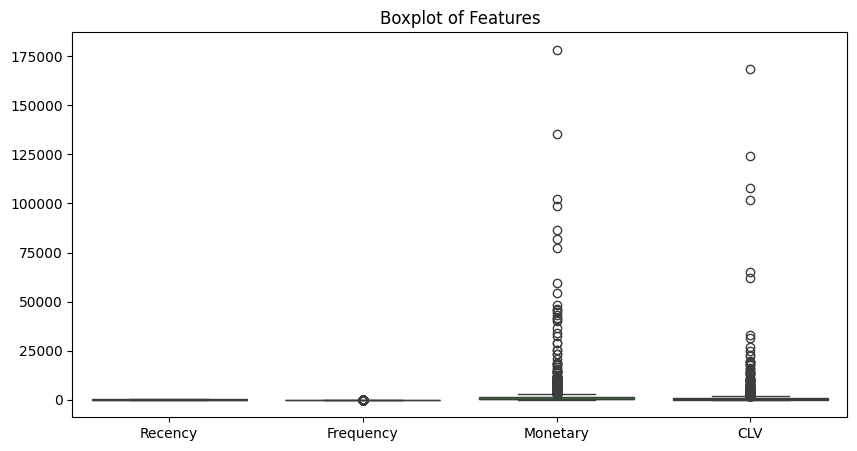

In [176]:
plt.figure(figsize=(10,5))

sns.boxplot(data=final_df[['Recency','Frequency','Monetary','CLV']])

plt.title("Boxplot of Features")

plt.show()

# Apply Log Transformation on CLV

In [177]:
final_df['CLV'] = np.log1p(final_df['CLV'])

# Feature Scaling

In [178]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = final_df[['Recency','Frequency','Monetary']]

X_scaled = scaler.fit_transform(X)


In [179]:
X = X_scaled

y = final_df['CLV']

In [180]:


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [181]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (2696, 3)
Testing Features : (674, 3)
Training Target : (2696,)
Testing Target : (674,)


# Building Regression Models & Model Evaluation


### Linear Regression

In [182]:


lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [183]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("RMSE :", lr_rmse)
print("MAE :", lr_mae)
print("R2 Score :", lr_r2)

Linear Regression Performance
RMSE : 3.151247436794812
MAE : 2.821609366470908
R2 Score : 0.08421417419981403


 # Ridge Regression



In [184]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)


In [185]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("RMSE :", ridge_rmse)
print("MAE :", ridge_mae)
print("R2 Score :", ridge_r2)

Ridge Regression Performance
RMSE : 3.1511032336731724
MAE : 2.8216581119717468
R2 Score : 0.0842979861859724


# Random Forest Regressor

In [186]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [187]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("RMSE :", rf_rmse)
print("MAE :", rf_mae)
print("R2 Score :", rf_r2)

Random Forest Performance
RMSE : 3.10587271493932
MAE : 2.622499645646095
R2 Score : 0.11039705188688698


# Gradient Boosting Regressor

In [188]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(

    random_state=42

)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

In [189]:
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting Performance")
print("RMSE :", gbr_rmse)
print("MAE :", gbr_mae)
print("R2 Score :", gbr_r2)


Gradient Boosting Performance
RMSE : 2.8939748627878474
MAE : 2.544240903304902
R2 Score : 0.227642415728178


# Compare All Models

In [190]:
results = pd.DataFrame({

    'Model': [

        'Linear Regression',

        'Ridge Regression',

        'Random Forest',

        'Gradient Boosting'

    ],

    'RMSE': [

        lr_rmse,

        ridge_rmse,

        rf_rmse,

        gbr_rmse

    ],

    'MAE': [

        lr_mae,

        ridge_mae,

        rf_mae,

        gbr_mae

    ],

    'R2 Score': [

        lr_r2,

        ridge_r2,

        rf_r2,

        gbr_r2

    ]

})

results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,3.151247,2.821609,0.084214
1,Ridge Regression,3.151103,2.821658,0.084298
2,Random Forest,3.105873,2.622500,0.110397
3,Gradient Boosting,2.893975,2.544241,0.227642


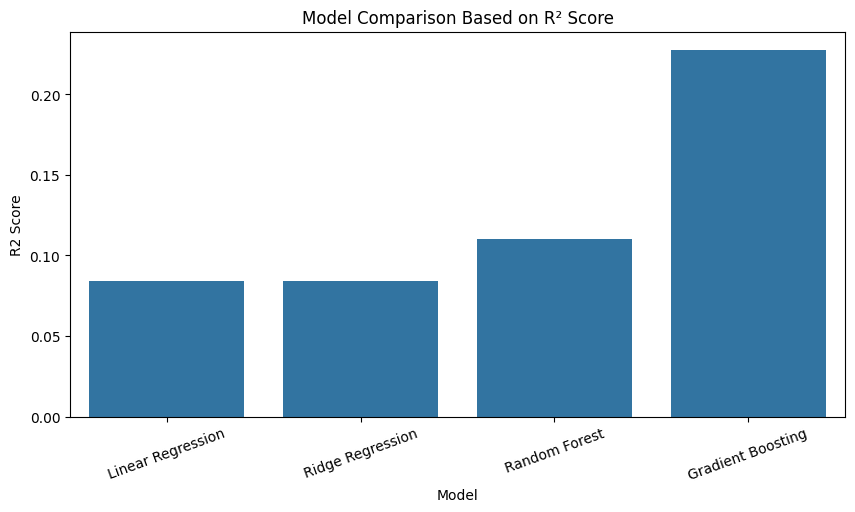

In [191]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x='Model',

    y='R2 Score'

)

plt.title("Model Comparison Based on R² Score")

plt.xticks(rotation=20)

plt.show()

# Fold Cross Validation

In [192]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    rf,

    X,

    y,

    cv=5,

    scoring='neg_root_mean_squared_error'

)

cv_rmse = -cv_scores

In [193]:
print("RMSE for Each Fold")

print(cv_rmse)

print()

print("Mean RMSE :", cv_rmse.mean())

print("Standard Deviation :", cv_rmse.std())

RMSE for Each Fold
[2.98643262 3.11621375 3.01135345 2.94081736 3.01035568]

Mean RMSE : 3.0130345718770952
Standard Deviation : 0.05758287031848557


 # K-Means Clustering
 The Elbow Method was used to determine the optimal number of customer clusters. WCSS decreases as the number of clusters increases because customers are grouped more precisely. The optimal value of K is selected at the point where the decrease in WCSS starts to slow significantly, forming an "elbow." This value provides a good balance between clustering accuracy and model simplicity.


#### Select Features for Clustering


In [194]:
cluster_data = final_df[['Recency', 'Frequency', 'Monetary']]


In [195]:
wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_data)

    wcss.append(kmeans.inertia_)

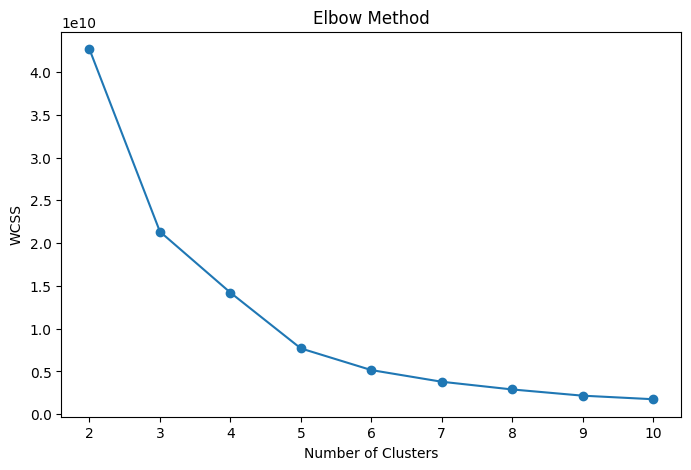

In [196]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Choose the value of K where the graph forms an "elbow." This is considered the optimal number of customer segments.

# Silhouette Score

In [197]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(cluster_data)

    score = silhouette_score(cluster_data, labels)

    print(f"K = {k}  Silhouette Score = {score:.3f}")

K = 2  Silhouette Score = 0.973
K = 3  Silhouette Score = 0.954
K = 4  Silhouette Score = 0.823
K = 5  Silhouette Score = 0.823
K = 6  Silhouette Score = 0.734
K = 7  Silhouette Score = 0.722
K = 8  Silhouette Score = 0.723
K = 9  Silhouette Score = 0.679
K = 10  Silhouette Score = 0.677


The Silhouette Score measures how well each customer fits within its assigned cluster.
Higher score = Better clustering.
Select the K with the highest reasonable score.

 # Build Final K-Means Model

In [198]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

final_df['Cluster'] = kmeans.fit_predict(cluster_data)

View Cluster Distribution

In [199]:
final_df['Cluster'].value_counts()


Cluster
2    3148
0     196
3      19
1       7
Name: count, dtype: int64

# PCA for 2D Visualization

In [200]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(cluster_data)

final_df['PCA1'] = pca_features[:,0]

final_df['PCA2'] = pca_features[:,1]

Visualize Customer Clusters

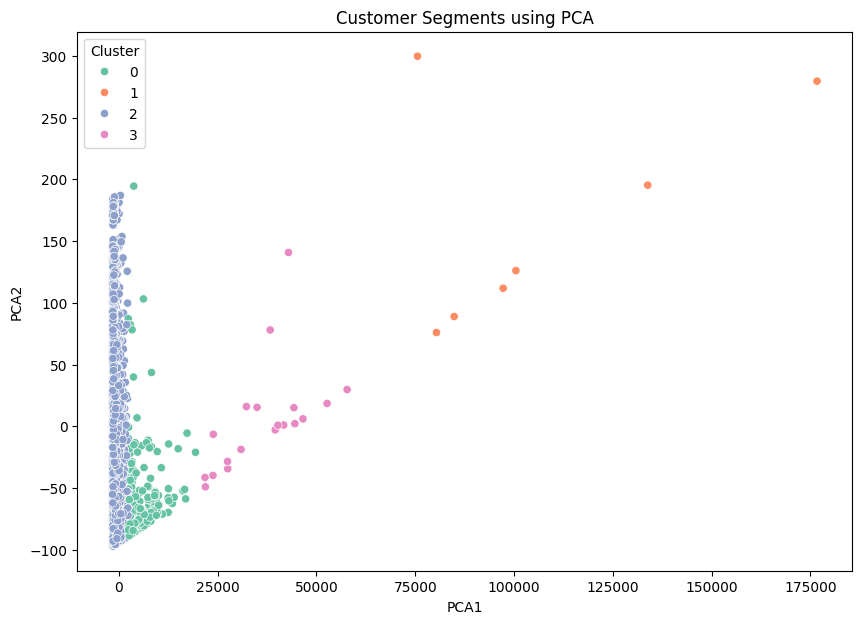

In [201]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=final_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments using PCA")

plt.show()

The PCA plot provides a 2D visualization of customer groups, making it easier to understand how different segments are separated.

In [202]:
cluster_summary = final_df.groupby('Cluster')[['Recency','Frequency','Monetary','CLV']].mean()

cluster_summary

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,26.887755,13.525510,7084.285408,7.286930
1,37.714286,37.428571,108617.487143,9.392446
2,99.675032,2.657560,820.417856,3.384088
3,23.736842,33.000000,38099.337895,8.537523


This table summarizes the average characteristics of each customer segment.

 # Assign Business Segment Names

In [203]:
segment_names = {

    0: "Champions",

    1: "Loyal Customers",

    2: "At Risk",

    3: "Lost Customers"

}

final_df['Segment'] = final_df['Cluster'].map(segment_names)

final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV,Cluster,PCA1,PCA2,Segment
0,12346.0,235,1,77183.60,0.000000,1,75564.312409,299.687116,Loyal Customers
1,12347.0,39,5,2790.86,7.326558,2,1172.160928,-53.427136,At Risk
2,12348.0,158,3,1487.24,5.739793,2,-131.707277,62.836884,At Risk
3,12350.0,219,1,334.40,0.000000,2,-1284.673874,121.428205,At Risk
4,12352.0,171,5,1561.81,6.851428,2,-57.163759,75.957468,At Risk


Business-friendly names make the clusters easier to understand and use for marketing strategies.

# Customer Segment Distribution

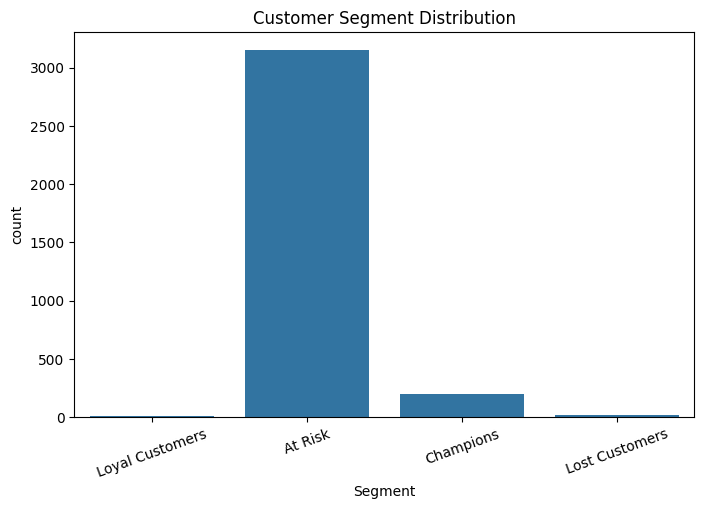

In [204]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x='Segment'
)

plt.xticks(rotation=20)

plt.title("Customer Segment Distribution")

plt.show()

This chart shows how customers are distributed across different business segments.

 # Basic Streamlit App (Starter Code)
